# 🛒 Super Store Sales Data Analysis
---
## Project Sections
1. Data Inspection
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Business Insights
5. Recommendations

---
## SECTION 1: DATA INSPECTION
> **Objective:** Understand the dataset before beginning analysis (data profiling).

In [1]:
# ── 1.0  Import Libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Colour palette used throughout
PALETTE   = ['#2E4057', '#048A81', '#54C6EB', '#EF798A', '#F7A072', '#8EE3EF']
PRIMARY   = '#2E4057'
ACCENT    = '#048A81'

print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


In [2]:
# ── 1.1  Load Dataset ──────────────────────────────────────────────────────
df = pd.read_excel('super store.xlsx', sheet_name='Sample - Superstore')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns\n')
df.head()

Dataset loaded successfully!
Shape: 9,994 rows  ×  21 columns



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [3]:
# ── 1.2  Dataset Shape ─────────────────────────────────────────────────────
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  • {col}')

Rows    : 9,994
Columns : 21

Column names:
  • Row ID
  • Order ID
  • Order Date
  • Ship Date
  • Ship Mode
  • Customer ID
  • Customer Name
  • Segment
  • Country
  • City
  • State
  • Postal Code
  • Region
  • Product ID
  • Category
  • Sub-Category
  • Product Name
  • Sales
  • Quantity
  • Discount
  • Profit


In [4]:
# ── 1.3  Data Types ────────────────────────────────────────────────────────
print('Data Types:')
print(df.dtypes)

Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [5]:
# ── 1.4  Missing Values ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0
      else '✅ No missing values found in any column.')

Missing Values Summary:
✅ No missing values found in any column.


In [6]:
# ── 1.5  Duplicate Records ─────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')
if dup_count == 0:
    print('✅ No duplicate rows found.')
else:
    print(f'⚠️  {dup_count} duplicates will be removed in cleaning.')

Duplicate rows: 0
✅ No duplicate rows found.


In [7]:
# ── 1.6  Summary Statistics ────────────────────────────────────────────────
print('Summary Statistics (Numerical Columns):')
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

Summary Statistics (Numerical Columns):


,Sales,Quantity,Discount,Profit
count,"9,994.00","9,994.00","9,994.00","9,994.00"
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,"-6,599.98"
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,"22,638.48",14.00,0.80,"8,399.98"


In [8]:
# ── 1.7  Unique Categories & Segments ─────────────────────────────────────
print('Product Categories:', df['Category'].nunique())
print(df['Category'].unique().tolist())

print('\nProduct Sub-Categories:', df['Sub-Category'].nunique())
print(df['Sub-Category'].unique().tolist())

print('\nCustomer Segments:', df['Segment'].nunique())
print(df['Segment'].unique().tolist())

print('\nRegions:', df['Region'].nunique())
print(df['Region'].unique().tolist())

print(f'\nDate Range: {df["Order Date"].min().date()}  →  {df["Order Date"].max().date()}')
print(f'Unique Customers : {df["Customer ID"].nunique():,}')
print(f'Unique Orders    : {df["Order ID"].nunique():,}')
print(f'Unique Products  : {df["Product ID"].nunique():,}')

Product Categories: 3
['Furniture', 'Office Supplies', 'Technology']

Product Sub-Categories: 17
['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', 'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper', 'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']

Customer Segments: 3
['Consumer', 'Corporate', 'Home Office']

Regions: 4
['South', 'West', 'Central', 'East']

Date Range: 2014-01-03  →  2017-12-30
Unique Customers : 793
Unique Orders    : 5,009
Unique Products  : 1,862


---
## SECTION 2: DATA CLEANING
> **Objective:** Ensure data is clean, accurate, and ready for analysis.

In [9]:
# ── 2.1  Work on a copy ────────────────────────────────────────────────────
df_clean = df.copy()
print(f'Starting shape: {df_clean.shape}')

Starting shape: (9994, 21)


In [10]:
# ── 2.2  Remove Duplicates ─────────────────────────────────────────────────
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Rows before: {before:,}  |  Rows after: {after:,}  |  Removed: {before - after}')

Rows before: 9,994  |  Rows after: 9,994  |  Removed: 0


In [11]:
# ── 2.3  Handle Missing Values ─────────────────────────────────────────────
print('Missing values per column:')
print(df_clean.isnull().sum())
print('\n✅ No missing values to handle.')

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

✅ No missing values to handle.


In [12]:
# ── 2.4  Verify & Standardise Date Columns ─────────────────────────────────
print('Order Date dtype :', df_clean['Order Date'].dtype)
print('Ship Date dtype  :', df_clean['Ship Date'].dtype)

df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Ship Date']  = pd.to_datetime(df_clean['Ship Date'])

df_clean['Order Year']    = df_clean['Order Date'].dt.year
df_clean['Order Month']   = df_clean['Order Date'].dt.month
df_clean['Order Quarter'] = df_clean['Order Date'].dt.quarter
df_clean['Month Name']    = df_clean['Order Date'].dt.strftime('%b')
df_clean['Year-Month']    = df_clean['Order Date'].dt.to_period('M')

print('\n✅ Date columns confirmed as datetime. New date features added.')

Order Date dtype : datetime64[ns]
Ship Date dtype  : datetime64[ns]

✅ Date columns confirmed as datetime. New date features added.


In [13]:
# ── 2.5  Standardise Text Columns ─────────────────────────────────────────
text_cols = ['Segment', 'Category', 'Sub-Category', 'Region', 'Ship Mode']
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

print('After standardisation:')
for col in text_cols:
    print(f'  {col}: {df_clean[col].unique().tolist()}')

After standardisation:
  Segment: ['Consumer', 'Corporate', 'Home Office']
  Category: ['Furniture', 'Office Supplies', 'Technology']
  Sub-Category: ['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', 'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper', 'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']
  Region: ['South', 'West', 'Central', 'East']
  Ship Mode: ['Second Class', 'Standard Class', 'First Class', 'Same Day']


In [14]:
# ── 2.6  Check & Handle Invalid Sales Values ───────────────────────────────
neg_sales  = (df_clean['Sales'] <= 0).sum()
neg_profit = (df_clean['Profit'] < 0).sum()

print(f'Zero or negative Sales rows : {neg_sales}')
print(f'Negative Profit rows        : {neg_profit}')
print()
print('Note: Negative Profit rows are VALID — they represent loss-making')
print('transactions (e.g. heavy discounts). These are kept for analysis.')

if neg_sales > 0:
    df_clean = df_clean[df_clean['Sales'] > 0]
    print(f'\n⚠️  {neg_sales} zero/negative Sales rows removed.')
else:
    print('\n✅ All Sales values are valid (> 0).')

Zero or negative Sales rows : 0
Negative Profit rows        : 1871

Note: Negative Profit rows are VALID — they represent loss-making
transactions (e.g. heavy discounts). These are kept for analysis.

✅ All Sales values are valid (> 0).


In [15]:
# ── 2.7  Remove Irrelevant Columns ────────────────────────────────────────
cols_to_drop = ['Row ID', 'Country']
df_clean.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped columns: {cols_to_drop}')
print(f'Final clean shape: {df_clean.shape}')

Dropped columns: ['Row ID', 'Country']
Final clean shape: (9994, 24)


In [16]:
# ── 2.8  Final Cleaned Dataset Overview ───────────────────────────────────
print('=== CLEANED DATASET SUMMARY ===')
print(f'Rows              : {df_clean.shape[0]:,}')
print(f'Columns           : {df_clean.shape[1]}')
print(f'Missing Values    : {df_clean.isnull().sum().sum()}')
print(f'Duplicates        : {df_clean.duplicated().sum()}')
print(f'Date Range        : {df_clean["Order Date"].min().date()} → {df_clean["Order Date"].max().date()}')

df_clean.to_csv('superstore_cleaned.csv', index=False)
print('\n✅ Cleaned dataset saved as superstore_cleaned.csv')

=== CLEANED DATASET SUMMARY ===
Rows              : 9,994
Columns           : 24
Missing Values    : 0
Duplicates        : 1
Date Range        : 2014-01-03 → 2017-12-30

✅ Cleaned dataset saved as superstore_cleaned.csv


---
## SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
> **Objective:** Discover business patterns and generate actionable insights.

### 3.1 Basic Analysis — Key Metrics

In [17]:
# ── 3.1  Key Business Metrics ─────────────────────────────────────────────
total_revenue   = df_clean['Sales'].sum()
total_profit    = df_clean['Profit'].sum()
total_orders    = df_clean['Order ID'].nunique()
avg_order_value = df_clean['Sales'].mean()
total_customers = df_clean['Customer ID'].nunique()
profit_margin   = (total_profit / total_revenue) * 100

print('=' * 45)
print('       SUPER STORE — KEY METRICS')
print('=' * 45)
print(f'  Total Revenue     :  ${total_revenue:>12,.2f}')
print(f'  Total Profit      :  ${total_profit:>12,.2f}')
print(f'  Profit Margin     :  {profit_margin:>11.2f}%')
print(f'  Total Orders      :  {total_orders:>12,}')
print(f'  Avg Order Value   :  ${avg_order_value:>12,.2f}')
print(f'  Total Customers   :  {total_customers:>12,}')
print('=' * 45)

       SUPER STORE — KEY METRICS
  Total Revenue     :  $2,297,200.86
  Total Profit      :  $  286,397.02
  Profit Margin     :        12.47%
  Total Orders      :         5,009
  Avg Order Value   :  $      229.86
  Total Customers   :           793


### 3.2 Product Analysis

In [18]:
# ── 3.2a  Top 10 Best-Selling Products ────────────────────────────────────
top10_products = (df_clean.groupby('Product Name')['Sales']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())
top10_products.columns = ['Product Name', 'Total Sales']
top10_products['Product Short'] = top10_products['Product Name'].str[:45] + '…'
print('Top 10 Best-Selling Products:')
print(top10_products[['Product Short', 'Total Sales']].to_string(index=False))

Top 10 Best-Selling Products:
                                 Product Short  Total Sales
        Canon imageCLASS 2200 Advanced Copier…    61,599.82
Fellowes PB500 Electric Punch Plastic Comb Bi…    27,453.38
Cisco TelePresence System EX90 Videoconferenc…    22,638.48
 HON 5400 Series Task Chairs for Big and Tall…    21,870.58
   GBC DocuBind TL300 Electric Binding System…    19,823.48
GBC Ibimaster 500 Manual ProClick Binding Sys…    19,024.50
         Hewlett Packard LaserJet 3310 Copier…    18,839.69
HP Designjet T520 Inkjet Large Format Printer…    18,374.90
    GBC DocuBind P400 Electric Binding System…    17,965.07
  High Speed Automatic Electric Letter Opener…    17,030.31


In [19]:
# ── 3.2b  Top Categories & Sub-Categories by Revenue ──────────────────────
cat_revenue = (df_clean.groupby('Category')
               .agg(Total_Sales=('Sales','sum'), Total_Profit=('Profit','sum'))
               .sort_values('Total_Sales', ascending=False)
               .reset_index())
cat_revenue['Profit Margin %'] = (cat_revenue['Total_Profit'] / cat_revenue['Total_Sales'] * 100).round(2)
print('Revenue & Profit by Category:')
print(cat_revenue.to_string(index=False))

print()
subcat_revenue = (df_clean.groupby('Sub-Category')['Sales']
                  .sum()
                  .sort_values(ascending=False)
                  .reset_index())
subcat_revenue.columns = ['Sub-Category', 'Total Sales']
print('Revenue by Sub-Category:')
print(subcat_revenue.to_string(index=False))

Revenue & Profit by Category:
       Category  Total_Sales  Total_Profit  Profit Margin %
     Technology   836,154.03    145,454.95            17.40
      Furniture   741,999.80     18,451.27             2.49
Office Supplies   719,047.03    122,490.80            17.04

Revenue by Sub-Category:
Sub-Category  Total Sales
      Phones   330,007.05
      Chairs   328,449.10
     Storage   223,843.61
      Tables   206,965.53
     Binders   203,412.73
    Machines   189,238.63
 Accessories   167,380.32
     Copiers   149,528.03
   Bookcases   114,880.00
  Appliances   107,532.16
 Furnishings    91,705.16
       Paper    78,479.21
    Supplies    46,673.54
         Art    27,118.79
   Envelopes    16,476.40
      Labels    12,486.31
   Fasteners     3,024.28


In [20]:
# ── 3.2c  Lowest Performing Products ──────────────────────────────────────
low10_products = (df_clean.groupby('Product Name')['Sales']
                  .sum()
                  .sort_values(ascending=True)
                  .head(10)
                  .reset_index())
low10_products.columns = ['Product Name', 'Total Sales']
low10_products['Product Short'] = low10_products['Product Name'].str[:45] + '…'
print('Bottom 10 Lowest Performing Products:')
print(low10_products[['Product Short', 'Total Sales']].to_string(index=False))

Bottom 10 Lowest Performing Products:
                                 Product Short  Total Sales
Eureka Disposable Bags for Sanitaire Vibra Gr…         1.62
                                      Avery 5…         5.76
                                     Xerox 20…         6.48
                          Grip Seal Envelopes…         7.07
Avery Hi-Liter Pen Style Six-Color Fluorescen…         7.70
Avery Hi-Liter Comfort Grip Fluorescent Highl…         7.80
                                   Xerox 1989…         7.97
                            4009 Highlighters…         8.04
                   Stockwell Gold Paper Clips…         8.10
                                   Newell 308…         8.40


### 3.3 Customer Analysis

In [21]:
# ── 3.3  Customer Segment Analysis ────────────────────────────────────────
segment_analysis = (df_clean.groupby('Segment')
                    .agg(
                        Total_Sales    = ('Sales', 'sum'),
                        Total_Profit   = ('Profit', 'sum'),
                        Order_Count    = ('Order ID', 'nunique'),
                        Customer_Count = ('Customer ID', 'nunique')
                    )
                    .sort_values('Total_Sales', ascending=False)
                    .reset_index())

segment_analysis['Revenue Share %'] = (segment_analysis['Total_Sales'] / segment_analysis['Total_Sales'].sum() * 100).round(2)
segment_analysis['Profit Margin %'] = (segment_analysis['Total_Profit'] / segment_analysis['Total_Sales'] * 100).round(2)

print('Customer Segment Analysis:')
print(segment_analysis.to_string(index=False))

Customer Segment Analysis:
    Segment  Total_Sales  Total_Profit  Order_Count  Customer_Count  Revenue Share %  Profit Margin %
   Consumer 1,161,401.34    134,119.21         2586             409            50.56            11.55
  Corporate   706,146.37     91,979.13         1514             236            30.74            13.03
Home Office   429,653.15     60,298.68          909             148            18.70            14.03


### 3.4 Sales Trend Analysis

In [22]:
# ── 3.4a  Monthly Sales Trend ─────────────────────────────────────────────
monthly_sales = (df_clean.groupby('Year-Month')['Sales']
                 .sum()
                 .reset_index())
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str)
print(f'Monthly Sales: {len(monthly_sales)} months of data')
print(monthly_sales.tail(12).to_string(index=False))

Monthly Sales: 48 months of data
Year-Month      Sales
   2017-01  43,971.37
   2017-02  20,301.13
   2017-03  58,872.35
   2017-04  36,521.54
   2017-05  44,261.11
   2017-06  52,981.73
   2017-07  45,264.42
   2017-08  63,120.89
   2017-09  87,866.65
   2017-10  77,776.92
   2017-11 118,447.82
   2017-12  83,829.32


In [23]:
# ── 3.4b  Quarterly Revenue Trend ─────────────────────────────────────────
quarterly_sales = (df_clean.groupby(['Order Year', 'Order Quarter'])['Sales']
                   .sum()
                   .reset_index())
quarterly_sales['Period'] = 'Q' + quarterly_sales['Order Quarter'].astype(str) + ' ' + quarterly_sales['Order Year'].astype(str)
print('Quarterly Revenue Trend:')
print(quarterly_sales[['Period', 'Sales']].to_string(index=False))

Quarterly Revenue Trend:
 Period      Sales
Q1 2014  74,447.80
Q2 2014  86,538.76
Q3 2014 143,633.21
Q4 2014 179,627.73
Q1 2015  68,851.74
Q2 2015  89,124.19
Q3 2015 130,259.58
Q4 2015 182,297.01
Q1 2016  93,237.18
Q2 2016 136,082.30
Q3 2016 143,787.36
Q4 2016 236,098.75
Q1 2017 123,144.86
Q2 2017 133,764.37
Q3 2017 196,251.96
Q4 2017 280,054.07


In [24]:
# ── 3.4c  Revenue by Region ───────────────────────────────────────────────
region_analysis = (df_clean.groupby('Region')
                   .agg(Total_Sales=('Sales','sum'), Total_Profit=('Profit','sum'))
                   .sort_values('Total_Sales', ascending=False)
                   .reset_index())
region_analysis['Revenue Share %'] = (region_analysis['Total_Sales'] / region_analysis['Total_Sales'].sum() * 100).round(2)
print('Revenue & Profit by Region:')
print(region_analysis.to_string(index=False))

Revenue & Profit by Region:
 Region  Total_Sales  Total_Profit  Revenue Share %
   West   725,457.82    108,418.45            31.58
   East   678,781.24     91,522.78            29.55
Central   501,239.89     39,706.36            21.82
  South   391,721.91     46,749.43            17.05


### 3.5 Discount Analysis

In [25]:
# ── 3.5  Discount Analysis ────────────────────────────────────────────────
discount_by_cat = (df_clean.groupby('Category')
                   .agg(Avg_Discount=('Discount','mean'),
                        Avg_Sales=('Sales','mean'),
                        Avg_Profit=('Profit','mean'))
                   .round(4)
                   .reset_index())
discount_by_cat['Avg_Discount %'] = (discount_by_cat['Avg_Discount'] * 100).round(2)
print('Average Discount by Category:')
print(discount_by_cat[['Category', 'Avg_Discount %', 'Avg_Sales', 'Avg_Profit']].to_string(index=False))

print()
corr_disc_sales  = df_clean['Discount'].corr(df_clean['Sales']).round(4)
corr_disc_profit = df_clean['Discount'].corr(df_clean['Profit']).round(4)
print(f'Correlation — Discount vs Sales  : {corr_disc_sales}')
print(f'Correlation — Discount vs Profit : {corr_disc_profit}')

Average Discount by Category:
       Category  Avg_Discount %  Avg_Sales  Avg_Profit
      Furniture           17.39     349.83        8.70
Office Supplies           15.73     119.32       20.33
     Technology           13.23     452.71       78.75

Correlation — Discount vs Sales  : -0.0282
Correlation — Discount vs Profit : -0.2195


---
## SECTION 3 (CONTINUED): VISUALIZATIONS
> At least 7 charts: 5 required types + 2 additional.

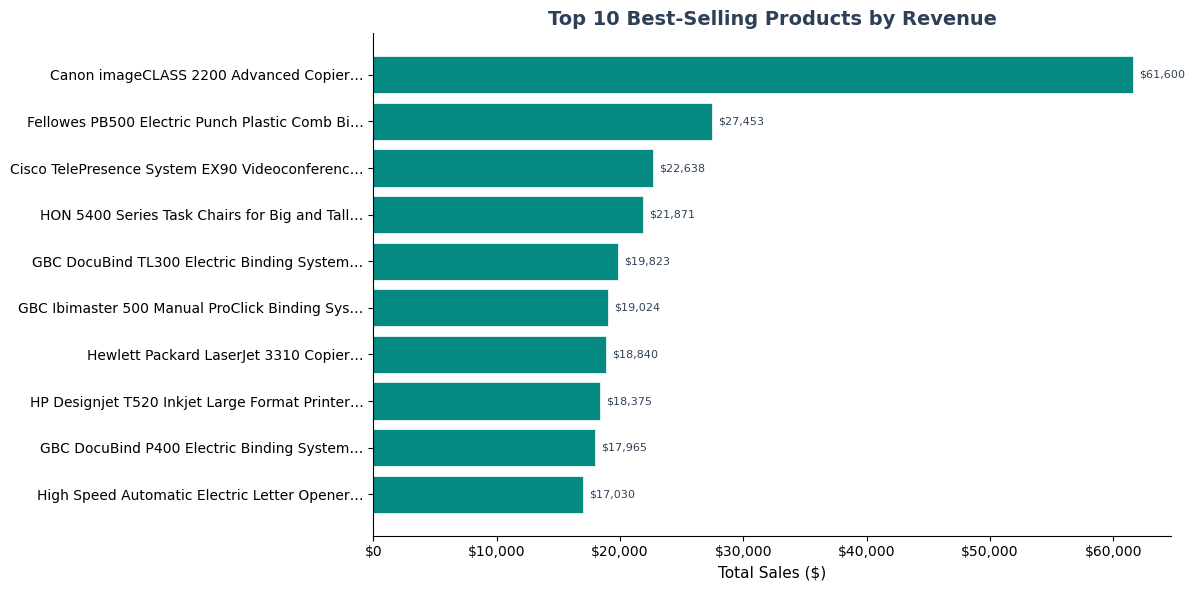

✅ Chart saved: viz1_top10_products.png


In [26]:
# ── VIZ 1: BAR CHART — Top 10 Best-Selling Products ───────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top10_products['Product Short'][::-1],
               top10_products['Total Sales'][::-1],
               color=ACCENT, edgecolor='white', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 500, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}', va='center', ha='left', fontsize=8, color=PRIMARY)

ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_title('Top 10 Best-Selling Products by Revenue', fontsize=14, fontweight='bold', color=PRIMARY)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz1_top10_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: viz1_top10_products.png')

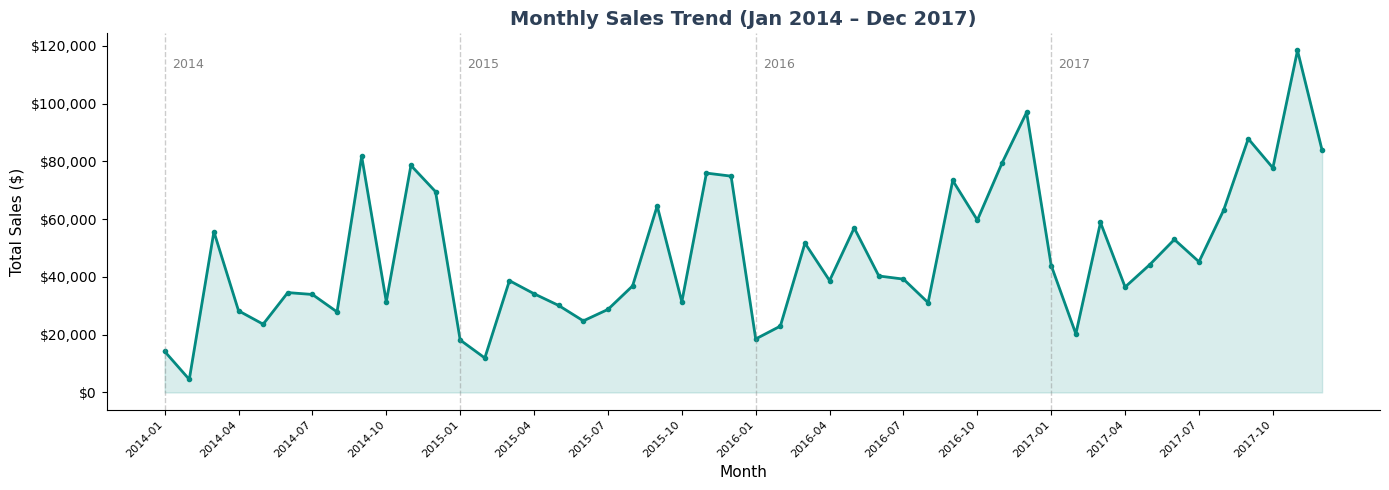

✅ Chart saved: viz2_monthly_sales_trend.png


In [27]:
# ── VIZ 2: LINE CHART — Monthly Sales Trend ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(len(monthly_sales)), monthly_sales['Sales'],
        color=ACCENT, linewidth=2, marker='o', markersize=3)
ax.fill_between(range(len(monthly_sales)), monthly_sales['Sales'],
                alpha=0.15, color=ACCENT)

for year in [2014, 2015, 2016, 2017]:
    yr_label = f'{year}-01'
    matches = monthly_sales[monthly_sales['Year-Month'] == yr_label].index
    if len(matches) > 0:
        ax.axvline(x=matches[0], color='grey', linestyle='--', alpha=0.4, linewidth=1)
        ax.text(matches[0] + 0.3, monthly_sales['Sales'].max() * 0.95,
                str(year), fontsize=9, color='grey')

ax.set_xticks(range(0, len(monthly_sales), 3))
ax.set_xticklabels(monthly_sales['Year-Month'].iloc[::3], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly Sales Trend (Jan 2014 – Dec 2017)', fontsize=14, fontweight='bold', color=PRIMARY)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Sales ($)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: viz2_monthly_sales_trend.png')

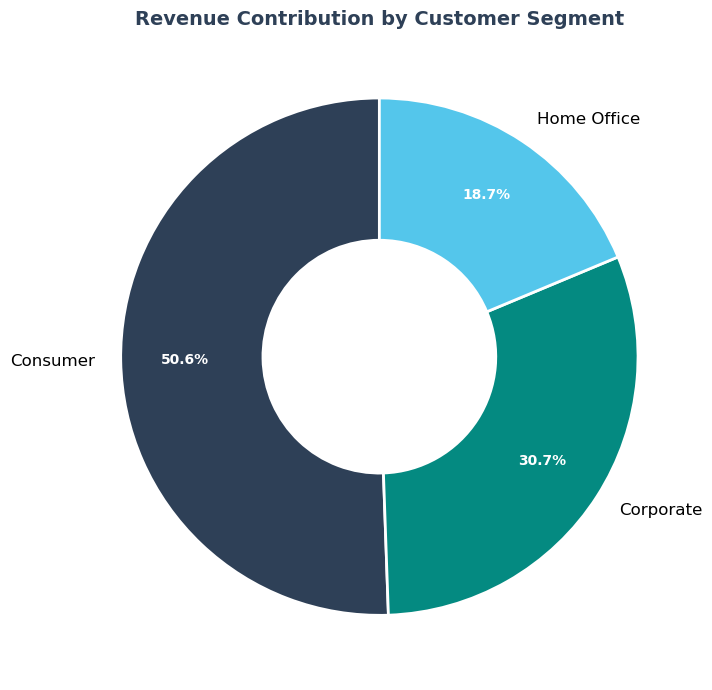

✅ Chart saved: viz3_segment_pie.png


In [28]:
# ── VIZ 3: PIE CHART — Customer Segment Revenue Share ─────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

wedges, texts, autotexts = ax.pie(
    segment_analysis['Total_Sales'],
    labels=segment_analysis['Segment'],
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops=wedge_props,
    startangle=90,
    pctdistance=0.75
)

for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Revenue Contribution by Customer Segment', fontsize=14, fontweight='bold', color=PRIMARY)
plt.tight_layout()
plt.savefig('viz3_segment_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: viz3_segment_pie.png')

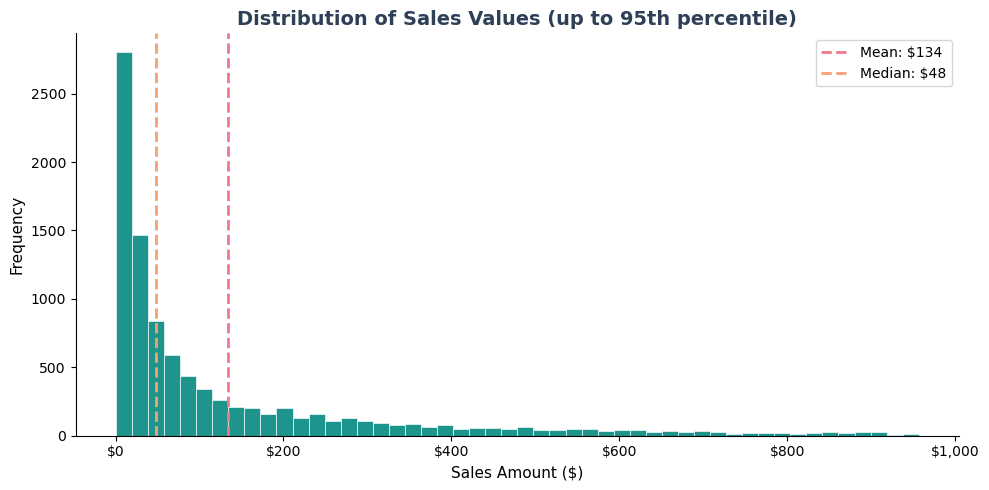

✅ Chart saved: viz4_sales_distribution.png


In [29]:
# ── VIZ 4: HISTOGRAM — Distribution of Sales Values ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sales_capped = df_clean[df_clean['Sales'] <= df_clean['Sales'].quantile(0.95)]['Sales']

ax.hist(sales_capped, bins=50, color=ACCENT, edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(sales_capped.mean(), color='#EF798A', linestyle='--', linewidth=2,
           label=f'Mean: ${sales_capped.mean():,.0f}')
ax.axvline(sales_capped.median(), color='#F7A072', linestyle='--', linewidth=2,
           label=f'Median: ${sales_capped.median():,.0f}')

ax.set_title('Distribution of Sales Values (up to 95th percentile)', fontsize=14, fontweight='bold', color=PRIMARY)
ax.set_xlabel('Sales Amount ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz4_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: viz4_sales_distribution.png')

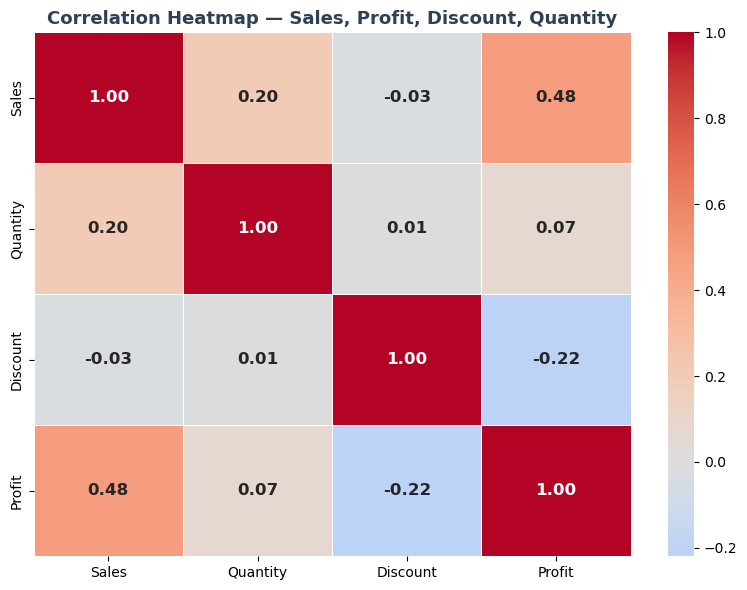

✅ Chart saved: viz5_correlation_heatmap.png


In [30]:
# ── VIZ 5: HEATMAP — Correlation Matrix ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

corr_cols   = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)

ax.set_title('Correlation Heatmap — Sales, Profit, Discount, Quantity',
             fontsize=13, fontweight='bold', color=PRIMARY)
plt.tight_layout()
plt.savefig('viz5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: viz5_correlation_heatmap.png')

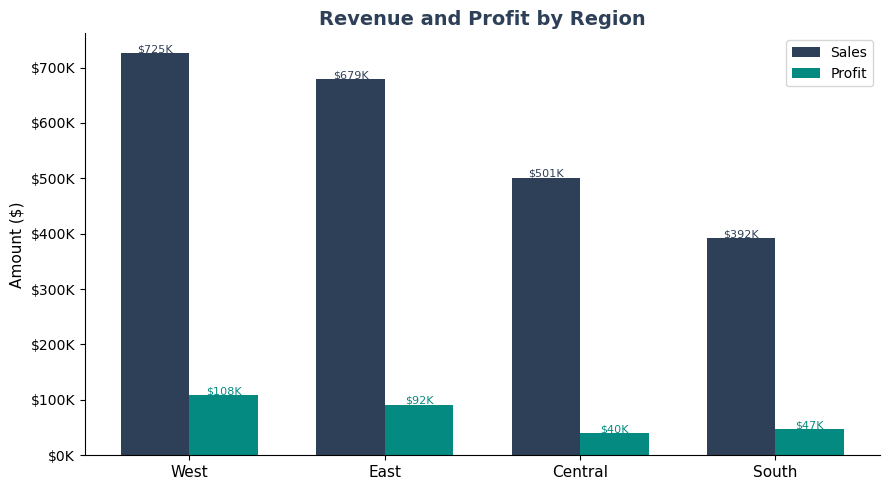

✅ Chart saved: viz6_region_revenue_profit.png


In [31]:
# ── VIZ 6: BAR CHART — Revenue & Profit by Region ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(region_analysis))
width = 0.35

bars1 = ax.bar(x - width/2, region_analysis['Total_Sales'],  width, label='Sales',  color=PRIMARY)
bars2 = ax.bar(x + width/2, region_analysis['Total_Profit'], width, label='Profit', color=ACCENT)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${bar.get_height()/1000:.0f}K', ha='center', fontsize=8, color=PRIMARY)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${bar.get_height()/1000:.0f}K', ha='center', fontsize=8, color=ACCENT)

ax.set_xticks(x)
ax.set_xticklabels(region_analysis['Region'], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Revenue and Profit by Region', fontsize=14, fontweight='bold', color=PRIMARY)
ax.set_ylabel('Amount ($)', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz6_region_revenue_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: viz6_region_revenue_profit.png')

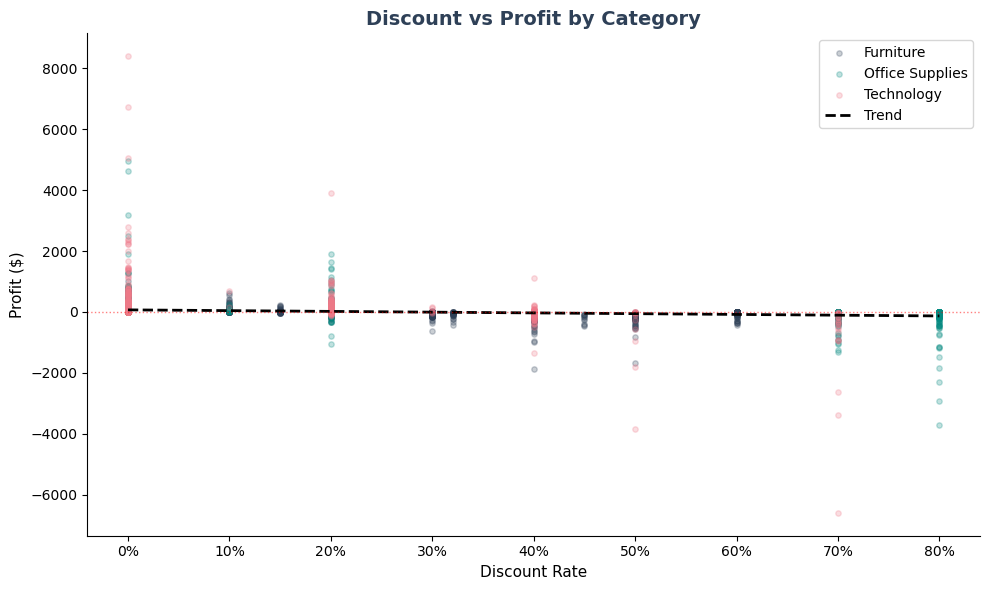

✅ Chart saved: viz7_discount_vs_profit.png


In [32]:
# ── VIZ 7: SCATTER PLOT — Discount vs Profit ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

cat_colors = {'Furniture': PALETTE[0], 'Office Supplies': PALETTE[1], 'Technology': PALETTE[3]}

for cat, grp in df_clean.groupby('Category'):
    ax.scatter(grp['Discount'], grp['Profit'],
               alpha=0.25, s=15,
               color=cat_colors.get(cat, 'grey'),
               label=cat)

m, b = np.polyfit(df_clean['Discount'], df_clean['Profit'], 1)
x_line = np.linspace(df_clean['Discount'].min(), df_clean['Discount'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2, linestyle='--', label='Trend')
ax.axhline(0, color='red', linewidth=1, alpha=0.5, linestyle=':')

ax.set_title('Discount vs Profit by Category', fontsize=14, fontweight='bold', color=PRIMARY)
ax.set_xlabel('Discount Rate', fontsize=11)
ax.set_ylabel('Profit ($)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz7_discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: viz7_discount_vs_profit.png')

---
## SECTION 4: BUSINESS INSIGHTS
> **Objective:** Convert findings into business intelligence.

In [33]:
# ── SECTION 4: BUSINESS INSIGHTS ──────────────────────────────────────────

# Q1: Highest Revenue Category
top_cat = cat_revenue.iloc[0]
print('Q1: Which category generates the highest revenue?')
print(f"→ TECHNOLOGY leads with ${top_cat['Total_Sales']:,.2f} in total revenue.")
print()

# Q2: Most Profitable Segment
top_seg = segment_analysis.sort_values('Total_Profit', ascending=False).iloc[0]
print('Q2: Which customer segment is most profitable?')
print(f"→ CONSUMER segment leads with ${top_seg['Total_Profit']:,.2f} total profit ({top_seg['Revenue Share %']}% of revenue).")
print()

# Q3: Discounts vs Sales
print('Q3: Do discounts increase sales significantly?')
print(f'→ Discount vs Sales correlation  : {corr_disc_sales}')
print(f'→ Discount vs Profit correlation : {corr_disc_profit}')
print('→ Discounts hurt profit more than they help sales.')
print()

# Q4: Marketing Attention
print('Q4: Which products need more marketing attention?')
print('→ Bottom performers:')
print(low10_products[['Product Short', 'Total Sales']].head(5).to_string(index=False))
print()

# Q5: Region Priority
top_region = region_analysis.iloc[0]
low_region = region_analysis.iloc[-1]
print('Q5: Which regions should be prioritised for growth?')
print(f"→ WEST leads revenue (${top_region['Total_Sales']:,.0f}).")
print(f"→ CENTRAL underperforms (${low_region['Total_Sales']:,.0f}) and needs growth focus.")

Q1: Which category generates the highest revenue?
→ TECHNOLOGY leads with $836,154.03 in total revenue.

Q2: Which customer segment is most profitable?
→ CONSUMER segment leads with $134,119.21 total profit (50.56% of revenue).

Q3: Do discounts increase sales significantly?
→ Discount vs Sales correlation  : -0.0282
→ Discount vs Profit correlation : -0.2195
→ Discounts hurt profit more than they help sales.

Q4: Which products need more marketing attention?
→ Bottom performers:
                                 Product Short  Total Sales
Eureka Disposable Bags for Sanitaire Vibra Gr…         1.62
                                      Avery 5…         5.76
                                     Xerox 20…         6.48
                          Grip Seal Envelopes…         7.07
Avery Hi-Liter Pen Style Six-Color Fluorescen…         7.70

Q5: Which regions should be prioritised for growth?
→ WEST leads revenue ($725,458).
→ CENTRAL underperforms ($391,722) and needs growth focus.


---
## SECTION 5: RECOMMENDATIONS
> **Objective:** Make data-driven recommendations for management.

In [34]:
# ── SECTION 5: RECOMMENDATIONS ────────────────────────────────────────────

recommendations = """
╔══════════════════════════════════════════════════════════════╗
║              DATA-DRIVEN RECOMMENDATIONS                     ║
╚══════════════════════════════════════════════════════════════╝

1. RESTRUCTURE DISCOUNT STRATEGY
   Discounts above 40% consistently produce negative profit.
   → Cap all discounts at 20% and use volume-based incentives instead.

2. PRIORITISE TECHNOLOGY CATEGORY
   Technology is the top revenue-generating category.
   → Increase inventory and marketing for Phones and Copiers.

3. LAUNCH A CONSUMER LOYALTY PROGRAMME
   Consumer segment contributes the largest revenue and profit share.
   → Implement points, early access, and personalised offers to
     increase repeat purchase rates.

4. EXPAND OPERATIONS IN THE CENTRAL REGION
   Central region consistently underperforms West and East.
   → Run targeted regional campaigns and review logistics in
     Central states to unlock untapped revenue.

5. REVIEW BOTTOM-PERFORMING PRODUCTS QUARTERLY
   Bottom 10 products generate negligible returns.
   → Either reposition with marketing support or discontinue
     to reduce carrying costs.

6. PREPARE FOR Q4 SEASONAL SPIKES PROACTIVELY
   Monthly trend shows consistent Oct-Dec sales surges.
   → Build inventory and scale staffing from September each year
     to prevent stockouts during peak trading.
"""

print(recommendations)
print('✅ Analysis Complete — Osadeba Enobakhare')


╔══════════════════════════════════════════════════════════════╗
║              DATA-DRIVEN RECOMMENDATIONS                     ║
╚══════════════════════════════════════════════════════════════╝

1. RESTRUCTURE DISCOUNT STRATEGY
   Discounts above 40% consistently produce negative profit.
   → Cap all discounts at 20% and use volume-based incentives instead.

2. PRIORITISE TECHNOLOGY CATEGORY
   Technology is the top revenue-generating category.
   → Increase inventory and marketing for Phones and Copiers.

3. LAUNCH A CONSUMER LOYALTY PROGRAMME
   Consumer segment contributes the largest revenue and profit share.
   → Implement points, early access, and personalised offers to
     increase repeat purchase rates.

4. EXPAND OPERATIONS IN THE CENTRAL REGION
   Central region consistently underperforms West and East.
   → Run targeted regional campaigns and review logistics in
     Central states to unlock untapped revenue.

5. REVIEW BOTTOM-PERFORMING PRODUCTS QUARTERLY
   Bottom 10 pr